# PowerPlus — XGBoost User Input Prediction Model

This notebook is the **user-input prediction stage** for the already-selected XGBoost model.

### Main improvements
- Uses `input()` for user interaction.
- Shows a clear **LABEL / TYPE / EXAMPLES / ANSWER TO TYPE** header before every input.
- Categorical inputs are **case-insensitive**: `owner`, `OWNER`, and `Owner` are normalized to the training value `Owner`.
- Categorical questions show a numbered list, which works like a terminal dropdown: enter the number or type the value.
- Saves the complete feature/type/value schema to CSV.
- Collects appliance/equipment inputs and performs appliance what-if sensitivity on total household demand.
- Produces 1-day, 7-day, and 30-day XGBoost forecasts.

**Important:** the `.pkl` must be the complete trained XGBoost artifact containing the prediction pipeline. A feature-name array alone is not sufficient.

In [1]:
# 1. IMPORTS
from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 120)


In [2]:
# 2. LOAD THE TRAINED XGBOOST MODEL + TRAINING DATA
def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.cwd().parent.parent.parent]
    for p in candidates:
        if (p / 'processed_data').exists():
            return p
    return Path.cwd()

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / 'processed_data'
MODEL_PKL = PROCESSED_DIR / 'powerplus_xgboost_forecast_model.pkl'
MODEL_DATA = PROCESSED_DIR / 'powerplus_model_data.csv'

if not MODEL_PKL.exists():
    raise FileNotFoundError(f'Model not found: {MODEL_PKL}. Run the successful XGBoost training notebook first.')
if not MODEL_DATA.exists():
    raise FileNotFoundError(f'Training/history data not found: {MODEL_DATA}')

artifact = joblib.load(MODEL_PKL)
if not isinstance(artifact, dict) or 'pipeline' not in artifact or 'feature_columns' not in artifact:
    raise TypeError(
        'The selected .pkl is not the complete trained XGBoost artifact. '
        'It must contain at least pipeline and feature_columns.'
    )

pipeline = artifact['pipeline']
feature_columns = list(artifact['feature_columns'])
TARGET = artifact.get('target', 'electricity_kwh')
DATE_COL = artifact.get('date_column', 'date')
CITY_COL = artifact.get('city_column', 'city')
HOUSE_COL = artifact.get('house_column', 'house')
numeric_features = list(artifact.get('numeric_features', []))
categorical_features = list(artifact.get('categorical_features', []))

df = pd.read_csv(MODEL_DATA)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
df = df.dropna(subset=[DATE_COL, TARGET]).sort_values([CITY_COL, HOUSE_COL, DATE_COL]).reset_index(drop=True)

if not numeric_features and not categorical_features:
    numeric_features = [c for c in feature_columns if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    categorical_features = [c for c in feature_columns if c not in numeric_features]

print('Model:', MODEL_PKL)
print('Training data:', MODEL_DATA)
print('Target:', TARGET)
print('Total model features:', len(feature_columns))
print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))
print('History:', df[DATE_COL].min().date(), 'to', df[DATE_COL].max().date())


Model: d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_xgboost_forecast_model.pkl
Training data: d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_model_data.csv
Target: electricity_kwh
Total model features: 82
Numeric features: 67
Categorical features: 15
History: 2023-08-15 to 2024-11-27


In [3]:
# 3. BUILD AND SAVE THE COMPLETE INPUT SCHEMA
# IMPORTANT: Run this cell BEFORE the user-input cell.
# It creates the exact 'label' column used later.

schema_rows = []

for c in feature_columns:
    if c in df.columns:
        s = df[c]
    else:
        s = pd.Series(dtype="object")

    if c in numeric_features:
        model_type = "numeric"
        python_input_type = "float"
        value_type = "number"
    elif c in categorical_features:
        model_type = "categorical"
        python_input_type = "str"
        value_type = "string/category"
    else:
        model_type = "numeric" if pd.api.types.is_numeric_dtype(s) else "categorical"
        python_input_type = "float" if model_type == "numeric" else "str"
        value_type = "number" if model_type == "numeric" else "string/category"

    vals = s.dropna()
    unique_vals = vals.astype(str).drop_duplicates().tolist()

    min_value = np.nan
    max_value = np.nan
    if model_type == "numeric" and len(vals):
        num = pd.to_numeric(vals, errors="coerce").dropna()
        if len(num):
            min_value = num.min()
            max_value = num.max()

    schema_rows.append({
        "label": c,
        "model_type": model_type,
        "pandas_dtype": str(s.dtype),
        "python_input_type": python_input_type,
        "value_type": value_type,
        "unique_count": int(vals.nunique(dropna=True)),
        "sample_values": " | ".join(unique_vals[:10]),
        "min": min_value,
        "max": max_value,
        "allowed_values_first_200": (
            " | ".join(sorted(unique_vals, key=lambda x: x.casefold())[:200])
            if model_type == "categorical" else ""
        ),
    })

schema_df = pd.DataFrame(schema_rows)

# Safety check: this prevents the KeyError: 'label'
required_schema_columns = [
    "label", "model_type", "pandas_dtype",
    "python_input_type", "value_type"
]
missing_schema_columns = [
    c for c in required_schema_columns if c not in schema_df.columns
]
if missing_schema_columns:
    raise RuntimeError(
        f"Schema creation failed. Missing columns: {missing_schema_columns}"
    )

SCHEMA_FILE = PROCESSED_DIR / "powerplus_user_input_schema.csv"
schema_df.to_csv(SCHEMA_FILE, index=False)

print("SCHEMA CREATED SUCCESSFULLY")
print("=" * 72)
print(f"Total features : {len(schema_df)}")
print(f"Numeric        : {(schema_df['model_type'] == 'numeric').sum()}")
print(f"Categorical    : {(schema_df['model_type'] == 'categorical').sum()}")
print(f"Saved          : {SCHEMA_FILE}")

display(schema_df)


SCHEMA CREATED SUCCESSFULLY
Total features : 82
Numeric        : 67
Categorical    : 15
Saved          : d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_user_input_schema.csv


,label,model_type,pandas_dtype,python_input_type,value_type,unique_count,sample_values,min,max,allowed_values_first_200
0,city,categorical,object,str,string/category,6,Islamabad | Karachi | Lahore | Multan | Peshawar | Skardu,NaN,NaN,Islamabad | Karachi | Lahore | Multan | Peshawar | Skardu
1,house,categorical,object,str,string/category,59,House#41 | House#42 | House#43 | House#44 | House#45 | House#46 | House#47 | House#48 | House#49 | House#50,NaN,NaN,House#1 | House#10 | House#11 | House#12 | House#13 | House#14 | House#15 | House#16 | House#17 | House#18 | House#1...
2,House,categorical,object,str,string/category,59,House#41 | House#42 | House#43 | House#44 | House#45 | House#46 | House#47 | House#48 | House#49 | House#50,NaN,NaN,House#1 | House#10 | House#11 | House#12 | House#13 | House#14 | House#15 | House#16 | House#17 | House#18 | House#1...
3,City,categorical,object,str,string/category,6,Islamabad | Karachi | Lahore | Multan | Peshawar | Skardu,NaN,NaN,Islamabad | Karachi | Lahore | Multan | Peshawar | Skardu
4,Owner/Rented,categorical,object,str,string/category,3,Owner | Rented | Residing as tenant,NaN,NaN,Owner | Rented | Residing as tenant
...,...,...,...,...,...,...,...,...,...,...
77,rolling_7_day_avg_kwh,numeric,float64,float,number,18556,0.0174523809523809 | 0.0168333333333333 | 0.0146666666666666 | 0.012547619047619 | 0.0130238095238095 | 0.0107380952...,0.0,69.448091,
78,rolling_14_day_avg_kwh,numeric,float64,float,number,18739,0.0111428571428571 | 0.0126190476190476 | 0.0133333333333333 | 0.0138571428571428 | 0.014297619047619 | 0.0139166666...,0.0,65.619451,
79,rolling_30_day_avg_kwh,numeric,float64,float,number,18850,0.0109611111111111 | 0.0113 | 0.0116833333333333 | 0.0113333333333333 | 0.0109944444444444 | 0.0113444444444444 | 0....,0.0,63.669771,
80,house_age,numeric,float64,float,number,37,9.0 | 10.0 | 11.0 | 12.0 | 3.0 | 4.0 | 2.0 | 28.0 | 29.0 | 7.0,1.0,64.000000,


In [4]:
# 4. IDENTIFY APPLIANCE / EQUIPMENT FEATURES
APPLIANCE_CANDIDATES = [
    'Air Conditioners', 'Air Coolers', 'Refrigerators', 'Washing Machines',
    'LED Bulbs', 'Tube Lights', 'Celling Fans', 'Ceiling Fans', 'Wall Fans',
    'Stand Fans', 'Water Dispensers', 'Water Pumps', 'Electric Cooker',
    'Electric heaters', 'Electric Heaters', 'Electric Irons', 'Sewing Machine',
    'Microwave Ovens', 'Geysers', 'UPS', 'Other Electronic Devices'
]

def norm_name(x):
    return ''.join(ch.lower() for ch in str(x) if ch.isalnum())

feature_norm = {norm_name(c): c for c in feature_columns}
appliance_columns = []
for candidate in APPLIANCE_CANDIDATES:
    n = norm_name(candidate)
    if n in feature_norm:
        appliance_columns.append(feature_norm[n])

# Also catch likely appliance/equipment labels if they exist in the dataset.
keywords = ['aircondition', 'aircool', 'refriger', 'washingmachine', 'ledbulb', 'tubel',
            'fan', 'waterdispenser', 'waterpump', 'electriccooker', 'electricheater',
            'electriciron', 'sewingmachine', 'microwave', 'geyser', 'ups', 'electronicdevice']
for c in feature_columns:
    n = norm_name(c)
    if any(k in n for k in keywords) and c not in appliance_columns:
        appliance_columns.append(c)

print('Detected appliance/equipment inputs:')
for i, c in enumerate(appliance_columns, 1):
    print(f'  {i:2d}. {c}')


Detected appliance/equipment inputs:
   1. Air Conditioners
   2. Air Coolers
   3. Refrigerators
   4. Washing Machines
   5. LED Bulbs
   6. Tube Lights
   7. Celling Fans
   8. Wall Fans
   9. Stand Fans
  10. Water Dispensers
  11. Water Pumps
  12. Electric Cooker
  13. Electric heaters
  14. Electric heaters
  15. Electric Irons
  16. Sewing Machine
  17. Microwave Ovens
  18. Geysers
  19. UPS
  20. Other Electronic Devices


In [5]:
# 5. CASE-INSENSITIVE INPUT HELPERS
def canonical_category(label, raw, allowed):
    '''Return the exact training category while accepting any letter case.'''
    text = str(raw).strip()
    lookup = {str(v).strip().casefold(): v for v in allowed}
    if text.casefold() in lookup:
        return lookup[text.casefold()]
    # Friendly whitespace normalization
    compact = ' '.join(text.split()).casefold()
    lookup2 = {' '.join(str(v).split()).casefold(): v for v in allowed}
    if compact in lookup2:
        return lookup2[compact]
    raise ValueError(f"{label}: '{raw}' is not a valid category. Choose a number from the list or type one of the shown values.")

def input_number(label, default=None, minimum=None, maximum=None, integer=False):
    while True:
        default_text = f' [default: {default}]' if default is not None and pd.notna(default) else ''
        print('\n' + '=' * 72)
        print(f'LABEL : {label}')
        print('TYPE  : INTEGER' if integer else 'TYPE  : NUMBER')
        print(f'ANSWER TO TYPE{default_text}')
        raw = input('> ').strip()
        if raw == '' and default is not None and pd.notna(default):
            value = float(default)
        else:
            try:
                value = float(raw)
            except Exception:
                print('Please type a number, for example 2 or 10.5.')
                continue
        if minimum is not None and value < minimum:
            print(f'Value must be >= {minimum}.')
            continue
        if maximum is not None and value > maximum:
            print(f'Value must be <= {maximum}.')
            continue
        if integer:
            if not float(value).is_integer():
                print('Please enter a whole number.')
                continue
            return int(value)
        return value

def input_category(label, allowed, default=None):
    allowed = list(allowed)
    while True:
        print('\n' + '=' * 72)
        print(f'LABEL : {label}')
        print('TYPE  : STRING / CATEGORY (case-insensitive)')
        print('OPTIONS — enter the NUMBER or type the VALUE:')
        for i, value in enumerate(allowed, 1):
            marker = '  <-- DEFAULT' if default is not None and str(value) == str(default) else ''
            print(f'  {i:3d}. {value}{marker}')
        if default is not None and pd.notna(default):
            print(f'ANSWER TO TYPE [press Enter for default: {default}]')
        else:
            print('ANSWER TO TYPE [number or category value]')
        raw = input('> ').strip()
        if raw == '' and default is not None and pd.notna(default):
            return canonical_category(label, default, allowed)
        if raw.isdigit() and 1 <= int(raw) <= len(allowed):
            return allowed[int(raw) - 1]
        try:
            return canonical_category(label, raw, allowed)
        except ValueError as e:
            print(e)

def latest_default(label, latest_profile):
    if label in latest_profile.index and pd.notna(latest_profile[label]):
        return latest_profile[label]
    return None

def allowed_values(label):
    if label in df.columns:
        return sorted(df[label].dropna().astype(str).drop_duplicates().tolist(), key=lambda x: x.lower())
    return []


In [6]:
# 6. SELECT CITY AND HOUSE — NUMBERED DROPDOWN-STYLE INPUT
cities = sorted(df[CITY_COL].dropna().astype(str).drop_duplicates().tolist(), key=lambda x: x.lower())
USER_CITY = input_category(CITY_COL, cities, default=cities[0] if cities else None)

houses = sorted(
    df.loc[df[CITY_COL].astype(str).str.casefold() == str(USER_CITY).casefold(), HOUSE_COL]
      .dropna().astype(str).drop_duplicates().tolist(),
    key=lambda x: x.lower()
)
USER_HOUSE = input_category(HOUSE_COL, houses, default=houses[0] if houses else None)

house_history = df[
    (df[CITY_COL].astype(str).str.casefold() == str(USER_CITY).casefold()) &
    (df[HOUSE_COL].astype(str).str.casefold() == str(USER_HOUSE).casefold())
].sort_values(DATE_COL).copy()
if house_history.empty:
    raise ValueError('No historical records found for the selected City/House.')
latest_profile = house_history.iloc[-1]

print('\n' + '=' * 72)
print('SELECTED HOUSEHOLD')
print('City :', USER_CITY)
print('House:', USER_HOUSE)
print('Latest historical date:', latest_profile[DATE_COL].date())



LABEL : city
TYPE  : STRING / CATEGORY (case-insensitive)
OPTIONS — enter the NUMBER or type the VALUE:
    1. Islamabad  <-- DEFAULT
    2. Karachi
    3. Lahore
    4. Multan
    5. Peshawar
    6. Skardu
ANSWER TO TYPE [press Enter for default: Islamabad]

LABEL : house
TYPE  : STRING / CATEGORY (case-insensitive)
OPTIONS — enter the NUMBER or type the VALUE:
    1. House#41  <-- DEFAULT
    2. House#42
    3. House#43
    4. House#44
    5. House#45
    6. House#46
    7. House#47
    8. House#48
    9. House#49
   10. House#50
ANSWER TO TYPE [press Enter for default: House#41]

SELECTED HOUSEHOLD
City : Islamabad
House: House#41
Latest historical date: 2024-10-30


In [7]:
# 7. GET FORECAST DATE AND HORIZON
default_start = df[DATE_COL].max() + pd.Timedelta(days=1)

while True:
    print('\n' + '=' * 72)
    print('LABEL : Forecast start date')
    print('TYPE  : DATE (YYYY-MM-DD)')
    print(f'ANSWER TO TYPE [default: {default_start.date()}]')
    raw = input('> ').strip()
    try:
        START_DATE = pd.Timestamp(raw) if raw else default_start
        if START_DATE <= df[DATE_COL].max():
            raise ValueError('Start date must be after the latest historical date.')
        break
    except Exception as e:
        print('Invalid date:', e)

print('\n' + '=' * 72)
print('LABEL : Forecast horizon')
print('TYPE  : INTEGER')
print('OPTIONS: 1 = one day | 7 = seven days | 30 = thirty days')
print('ANSWER TO TYPE [default: 7]')
while True:
    raw = input('> ').strip() or '7'
    try:
        HORIZON_DAYS = int(raw)
        if HORIZON_DAYS in (1, 7, 30):
            break
        print('Please enter 1, 7, or 30.')
    except ValueError:
        print('Please enter 1, 7, or 30.')



LABEL : Forecast start date
TYPE  : DATE (YYYY-MM-DD)
ANSWER TO TYPE [default: 2024-11-28]

LABEL : Forecast horizon
TYPE  : INTEGER
OPTIONS: 1 = one day | 7 = seven days | 30 = thirty days
ANSWER TO TYPE [default: 7]


In [8]:
# 8. USER INPUT FOR EVERY MODEL FEATURE
# Run this cell AFTER cells 1-7.
# Every input has: LABEL / TYPE / OPTIONS / ANSWER TO TYPE.
# Categorical input is CASE-INSENSITIVE.

if "schema_df" not in globals():
    raise RuntimeError("Run Cell 3 (BUILD AND SAVE THE COMPLETE INPUT SCHEMA) first.")

if "label" not in schema_df.columns:
    raise RuntimeError(
        "schema_df does not contain 'label'. Re-run Cell 3 to rebuild schema_df."
    )

USER_INPUTS = {
    CITY_COL: USER_CITY,
    HOUSE_COL: USER_HOUSE
}
input_rows = []

calendar_names = {
    "year", "month", "day", "day_of_week",
    "week_of_year", "day_of_year", "is_weekend", "season"
}

def get_meta(label):
    match = schema_df[schema_df["label"].astype(str) == str(label)]
    if match.empty:
        raise KeyError(
            f"Feature '{label}' is in feature_columns but not in schema_df. "
            "Re-run Cell 3."
        )
    return match.iloc[0]

for label in feature_columns:
    if label in {CITY_COL, HOUSE_COL}:
        continue

    meta = get_meta(label)
    model_type = str(meta["model_type"])
    default = latest_default(label, latest_profile)

    # Calendar values are derived from the forecast date.
    if label in calendar_names:
        calendar_defaults = {
            "year": START_DATE.year,
            "month": START_DATE.month,
            "day": START_DATE.day,
            "day_of_week": START_DATE.dayofweek,
            "week_of_year": int(START_DATE.isocalendar().week),
            "day_of_year": START_DATE.dayofyear,
            "is_weekend": int(START_DATE.dayofweek >= 5),
        }

        if label in calendar_defaults:
            default = calendar_defaults[label]

        if label == "season":
            default = (
                "Winter" if START_DATE.month in [12, 1, 2]
                else "Spring" if START_DATE.month in [3, 4, 5]
                else "Summer" if START_DATE.month in [6, 7, 8]
                else "Autumn"
            )

    if model_type == "categorical":
        allowed = allowed_values(label)

        if not allowed:
            # If no values exist in the training data, ask for a string.
            print("\n" + "=" * 72)
            print(f"LABEL : {label}")
            print("TYPE  : STRING / CATEGORY")
            print("ANSWER TO TYPE: enter a text value")
            raw = input("> ").strip()
            value = raw if raw else default
        else:
            value = input_category(
                label,
                allowed,
                default=default
            )

    else:
        lname = norm_name(label)

        integer = (
            label in appliance_columns
            or any(k in lname for k in [
                "numberof", "noof", "people", "residents",
                "floors", "rooms", "washrooms", "stores",
                "children", "adults", "seniors"
            ])
        )

        value = input_number(
            label,
            default=default,
            minimum=0 if integer else None,
            integer=integer
        )

    USER_INPUTS[label] = value

    input_rows.append({
        "label": label,
        "model_type": model_type,
        "pandas_dtype": meta["pandas_dtype"],
        "python_input_type": meta["python_input_type"],
        "value_type": meta["value_type"],
        "user_value": value,
        "source": (
            "user input"
            if str(value) != str(default)
            else "default / latest / derived"
        ),
    })

user_input_df = pd.DataFrame(input_rows)

USER_INPUT_FILE = (
    PROCESSED_DIR / "powerplus_user_input_values.csv"
)
user_input_df.to_csv(USER_INPUT_FILE, index=False)

print("\n" + "=" * 72)
print("USER INPUT SUMMARY")
print("=" * 72)
print(f"Features entered: {len(user_input_df)}")
print(f"Saved answers   : {USER_INPUT_FILE}")

display(user_input_df)



LABEL : House
TYPE  : STRING / CATEGORY (case-insensitive)
OPTIONS — enter the NUMBER or type the VALUE:
    1. House#1
    2. House#10
    3. House#11
    4. House#12
    5. House#13
    6. House#14
    7. House#15
    8. House#16
    9. House#17
   10. House#18
   11. House#19
   12. House#2
   13. House#20
   14. House#21
   15. House#22
   16. House#23
   17. House#24
   18. House#25
   19. House#26
   20. House#27
   21. House#28
   22. House#29
   23. House#3
   24. House#30
   25. House#31
   26. House#32
   27. House#33
   28. House#34
   29. House#35
   30. House#36
   31. House#37
   32. House#38
   33. House#39
   34. House#4
   35. House#40
   36. House#41  <-- DEFAULT
   37. House#42
   38. House#43
   39. House#44
   40. House#45
   41. House#46
   42. House#47
   43. House#48
   44. House#49
   45. House#5
   46. House#50
   47. House#51
   48. House#52
   49. House#53
   50. House#54
   51. House#55
   52. House#56
   53. House#57
   54. House#58
   55. House#59
   56.

,label,model_type,pandas_dtype,python_input_type,value_type,user_value,source
0,House,categorical,object,str,string/category,House#1,user input
1,City,categorical,object,str,string/category,Islamabad,default / latest / derived
2,Owner/Rented,categorical,object,str,string/category,Owner,default / latest / derived
3,No. of people (Temp+Perm),numeric,float64,float,number,3,user input
4,No. of Permanent residents,numeric,float64,float,number,1,user input
...,...,...,...,...,...,...,...
75,rolling_7_day_avg_kwh,numeric,float64,float,number,0.0,default / latest / derived
76,rolling_14_day_avg_kwh,numeric,float64,float,number,0.0,default / latest / derived
77,rolling_30_day_avg_kwh,numeric,float64,float,number,0.0,default / latest / derived
78,house_age,numeric,float64,float,number,10.0,default / latest / derived


In [9]:
# 9. HISTORICAL DEMAND + WEATHER HELPERS
LAG_MAP = {lag: next((c for c in [f'lag_{lag}_day_kwh', f'Lag_{lag}', f'lag_{lag}'] if c in feature_columns), None) for lag in [1,2,3,7,14,30]}
ROLLING_MAP = {w: next((c for c in [f'rolling_{w}_day_avg_kwh', f'Rolling_{w}', f'rolling_{w}'] if c in feature_columns), None) for w in [3,7,14,30]}

WEATHER_COLUMNS = [
    'temperature_mean', 'humidity_mean', 'dew_mean', 'wind_speed_mean',
    'wind_direction_mean', 'pressure_mean', 'solar_radiation_mean',
    'temperature_max', 'humidity_max', 'wind_speed_max', 'solar_radiation_max',
    'uv_index_max', 'precipitation_sum', 'solar_energy_sum',
]

def season_from_month(month):
    return 'Winter' if month in [12,1,2] else 'Spring' if month in [3,4,5] else 'Summer' if month in [6,7,8] else 'Autumn'

def seasonal_weather(city, dates):
    h = df.copy()
    h['_month'] = h[DATE_COL].dt.month
    h['_doy'] = h[DATE_COL].dt.dayofyear
    ch = h[h[CITY_COL].astype(str).str.casefold() == str(city).casefold()]
    rows = []
    for d in dates:
        exact = ch[ch['_doy'] == d.dayofyear]
        source = exact if len(exact) else ch[ch['_month'] == d.month]
        row = {CITY_COL: city, DATE_COL: d}
        for col in WEATHER_COLUMNS:
            if col in feature_columns and col in df.columns:
                vals = pd.to_numeric(source[col], errors='coerce').dropna()
                row[col] = vals.mean() if len(vals) else pd.to_numeric(df[col], errors='coerce').median()
        rows.append(row)
    return pd.DataFrame(rows)

print('Lag features:', LAG_MAP)
print('Rolling features:', ROLLING_MAP)


Lag features: {1: 'lag_1_day_kwh', 2: 'lag_2_day_kwh', 3: 'lag_3_day_kwh', 7: 'lag_7_day_kwh', 14: 'lag_14_day_kwh', 30: 'lag_30_day_kwh'}
Rolling features: {3: 'rolling_3_day_avg_kwh', 7: 'rolling_7_day_avg_kwh', 14: 'rolling_14_day_avg_kwh', 30: 'rolling_30_day_avg_kwh'}


In [10]:
# 10. BUILD FUTURE MODEL ROW
def build_future_row(future_date, demand_history, weather_row=None):
    row = latest_profile.to_dict()
    row[CITY_COL] = USER_CITY
    row[HOUSE_COL] = USER_HOUSE

    # Apply user inputs first.
    for c, v in USER_INPUTS.items():
        if c in feature_columns and v is not None:
            row[c] = v

    # Calendar features are refreshed for each forecast day.
    calendar = {
        'year': future_date.year,
        'month': future_date.month,
        'day': future_date.day,
        'day_of_week': future_date.dayofweek,
        'week_of_year': int(future_date.isocalendar().week),
        'day_of_year': future_date.dayofyear,
        'is_weekend': int(future_date.dayofweek >= 5),
        'season': season_from_month(future_date.month),
    }
    for c, v in calendar.items():
        if c in feature_columns:
            row[c] = v

    # Keep total appliance count consistent when the feature exists.
    if 'total_appliance_count' in feature_columns and appliance_columns:
        total = 0.0
        for c in appliance_columns:
            try:
                total += float(row.get(c, 0)) if pd.notna(row.get(c, 0)) else 0.0
            except Exception:
                pass
        row['total_appliance_count'] = total

    # Refresh house age if build year is available.
    build_year_candidates = [c for c in feature_columns if norm_name(c) in {'buildyearofhouse','buildyear'}]
    if 'house_age' in feature_columns and build_year_candidates:
        by = row.get(build_year_candidates[0])
        if pd.notna(by):
            row['house_age'] = max(0, future_date.year - float(by))

    if weather_row is not None:
        for c in WEATHER_COLUMNS:
            if c in feature_columns and c in weather_row.index and pd.notna(weather_row[c]):
                row[c] = weather_row[c]

    # Recursive lag values.
    for lag, col in LAG_MAP.items():
        if col is None:
            continue
        target_date = future_date - pd.Timedelta(days=lag)
        m = demand_history[demand_history[DATE_COL] == target_date]
        if not m.empty:
            row[col] = float(m[TARGET].iloc[-1])
        elif future_date == START_DATE and col in USER_INPUTS and USER_INPUTS[col] is not None:
            row[col] = float(USER_INPUTS[col])
        else:
            row[col] = float(demand_history[TARGET].iloc[-1])

    past = demand_history[demand_history[DATE_COL] < future_date].sort_values(DATE_COL)[TARGET]
    for window, col in ROLLING_MAP.items():
        if col is None:
            continue
        if len(past) >= window:
            row[col] = float(past.tail(window).mean())
        elif future_date == START_DATE and col in USER_INPUTS and USER_INPUTS[col] is not None:
            row[col] = float(USER_INPUTS[col])
        elif len(past):
            row[col] = float(past.mean())

    # Enforce expected model types.
    for c in numeric_features:
        if c in row:
            row[c] = pd.to_numeric(pd.Series([row[c]]), errors='coerce').iloc[0]
    for c in categorical_features:
        if c in row and pd.notna(row[c]):
            row[c] = str(row[c])

    return pd.DataFrame([row]).reindex(columns=feature_columns)


In [11]:
# 11. RUN XGBOOST PREDICTION
def predict_for_user(horizon_days):
    dates = pd.date_range(START_DATE, periods=horizon_days, freq='D')
    demand = house_history[[DATE_COL, TARGET]].copy().dropna()
    weather_proxy = seasonal_weather(USER_CITY, dates)
    results = []

    for d in dates:
        wr = None
        if not weather_proxy.empty:
            m = weather_proxy[weather_proxy[DATE_COL] == d]
            if not m.empty:
                wr = m.iloc[0]
        X_future = build_future_row(d, demand, weather_row=wr)
        pred = max(0.0, float(pipeline.predict(X_future)[0]))
        results.append({
            'date': d,
            'city': USER_CITY,
            'house': USER_HOUSE,
            'predicted_electricity_kwh': pred,
        })
        demand = pd.concat([demand, pd.DataFrame([{DATE_COL: d, TARGET: pred}])], ignore_index=True)
    return pd.DataFrame(results)

forecast_1 = predict_for_user(1)
forecast_7 = predict_for_user(7)
forecast_30 = predict_for_user(30)

print('\n' + '=' * 72)
print('XGBOOST USER INPUT PREDICTION OUTPUT')
print('=' * 72)
print('City                 :', USER_CITY)
print('House                :', USER_HOUSE)
print('Forecast start       :', START_DATE.date())
print('1-day predicted kWh  :', round(forecast_1['predicted_electricity_kwh'].sum(), 4))
print('7-day predicted kWh  :', round(forecast_7['predicted_electricity_kwh'].sum(), 4))
print('30-day predicted kWh :', round(forecast_30['predicted_electricity_kwh'].sum(), 4))

print('\n1-DAY OUTPUT')
display(forecast_1)
print('\n7-DAY OUTPUT')
display(forecast_7)
print('\n30-DAY OUTPUT')
display(forecast_30)



XGBOOST USER INPUT PREDICTION OUTPUT
City                 : Islamabad
House                : House#41
Forecast start       : 2026-11-23
1-day predicted kWh  : 0.0235
7-day predicted kWh  : 0.1642
30-day predicted kWh : 0.7037

1-DAY OUTPUT


,date,city,house,predicted_electricity_kwh
0,2026-11-23,Islamabad,House#41,0.023456



7-DAY OUTPUT


,date,city,house,predicted_electricity_kwh
0,2026-11-23,Islamabad,House#41,0.023456
1,2026-11-24,Islamabad,House#41,0.023456
2,2026-11-25,Islamabad,House#41,0.023456
3,2026-11-26,Islamabad,House#41,0.023456
4,2026-11-27,Islamabad,House#41,0.023456
5,2026-11-28,Islamabad,House#41,0.023456
6,2026-11-29,Islamabad,House#41,0.023456



30-DAY OUTPUT


,date,city,house,predicted_electricity_kwh
0,2026-11-23,Islamabad,House#41,0.023456
1,2026-11-24,Islamabad,House#41,0.023456
2,2026-11-25,Islamabad,House#41,0.023456
3,2026-11-26,Islamabad,House#41,0.023456
4,2026-11-27,Islamabad,House#41,0.023456
5,2026-11-28,Islamabad,House#41,0.023456
6,2026-11-29,Islamabad,House#41,0.023456
7,2026-11-30,Islamabad,House#41,0.023456
8,2026-12-01,Islamabad,House#41,0.023456
9,2026-12-02,Islamabad,House#41,0.023456


In [12]:
# 12. APPLIANCE-LEVEL WHAT-IF ANALYSIS
# This estimates the change in TOTAL household predicted kWh when one appliance count increases by 1.
# It is model sensitivity, not measured appliance-specific consumption.
BASELINE = float(forecast_1['predicted_electricity_kwh'].iloc[0])
sensitivity_rows = []

for appliance in appliance_columns:
    base = USER_INPUTS.get(appliance, latest_default(appliance, latest_profile))
    try:
        base = 0.0 if pd.isna(base) else float(base)
    except Exception:
        continue

    USER_INPUTS[appliance] = base + 1
    changed_pred = float(predict_for_user(1)['predicted_electricity_kwh'].iloc[0])
    USER_INPUTS[appliance] = base

    sensitivity_rows.append({
        'appliance': appliance,
        'base_count': base,
        'count_plus_1': base + 1,
        'baseline_total_kwh': BASELINE,
        'plus_1_total_kwh': changed_pred,
        'model_delta_kwh': changed_pred - BASELINE,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
if not sensitivity_df.empty:
    sensitivity_df = sensitivity_df.sort_values('model_delta_kwh', ascending=False)
display(sensitivity_df)


,appliance,base_count,count_plus_1,baseline_total_kwh,plus_1_total_kwh,model_delta_kwh
0,Air Conditioners,2.0,3.0,0.023456,0.023456,0.0
1,Air Coolers,1.0,2.0,0.023456,0.023456,0.0
18,UPS,0.0,1.0,0.023456,0.023456,0.0
17,Geysers,1.0,2.0,0.023456,0.023456,0.0
16,Microwave Ovens,1.0,2.0,0.023456,0.023456,0.0
15,Sewing Machine,1.0,2.0,0.023456,0.023456,0.0
14,Electric Irons,1.0,2.0,0.023456,0.023456,0.0
13,Electric heaters,1.0,2.0,0.023456,0.023456,0.0
12,Electric heaters,1.0,2.0,0.023456,0.023456,0.0
11,Electric Cooker,1.0,2.0,0.023456,0.023456,0.0


In [13]:
# 13. SAVE ALL OUTPUTS
OUT_1 = PROCESSED_DIR / 'powerplus_user_input_forecast_1_day.csv'
OUT_7 = PROCESSED_DIR / 'powerplus_user_input_forecast_7_day.csv'
OUT_30 = PROCESSED_DIR / 'powerplus_user_input_forecast_30_day.csv'
OUT_SENS = PROCESSED_DIR / 'powerplus_appliance_sensitivity.csv'

forecast_1.to_csv(OUT_1, index=False)
forecast_7.to_csv(OUT_7, index=False)
forecast_30.to_csv(OUT_30, index=False)
sensitivity_df.to_csv(OUT_SENS, index=False)

print('Saved prediction outputs:')
for p in [SCHEMA_FILE, USER_INPUT_FILE, OUT_1, OUT_7, OUT_30, OUT_SENS]:
    print(' -', p)


Saved prediction outputs:
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_user_input_schema.csv
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_user_input_values.csv
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_user_input_forecast_1_day.csv
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_user_input_forecast_7_day.csv
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_user_input_forecast_30_day.csv
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_appliance_sensitivity.csv



POWERPLUS — XGBOOST USER INPUT PREDICTION OUTPUT
City              : Islamabad
House             : House#41
Forecast start    : 2026-11-23
Horizon requested : 7 day(s)
--------------------------------------------------------------------------------
1-Day predicted household demand  : 0.0235 kWh
7-Day predicted household demand  : 0.1642 kWh
30-Day predicted household demand : 0.7037 kWh

SELECTED USER INPUTS


,label,model_type,pandas_dtype,python_input_type,user_value
0,House,categorical,object,str,House#1
1,City,categorical,object,str,Islamabad
2,Owner/Rented,categorical,object,str,Owner
3,No. of people (Temp+Perm),numeric,float64,float,3
4,No. of Permanent residents,numeric,float64,float,1
...,...,...,...,...,...
75,rolling_7_day_avg_kwh,numeric,float64,float,0.0
76,rolling_14_day_avg_kwh,numeric,float64,float,0.0
77,rolling_30_day_avg_kwh,numeric,float64,float,0.0
78,house_age,numeric,float64,float,10.0



PREDICTION OUTPUT


,date,city,house,predicted_electricity_kwh
0,2026-11-23,Islamabad,House#41,0.023456
1,2026-11-24,Islamabad,House#41,0.023456
2,2026-11-25,Islamabad,House#41,0.023456
3,2026-11-26,Islamabad,House#41,0.023456
4,2026-11-27,Islamabad,House#41,0.023456
5,2026-11-28,Islamabad,House#41,0.023456
6,2026-11-29,Islamabad,House#41,0.023456


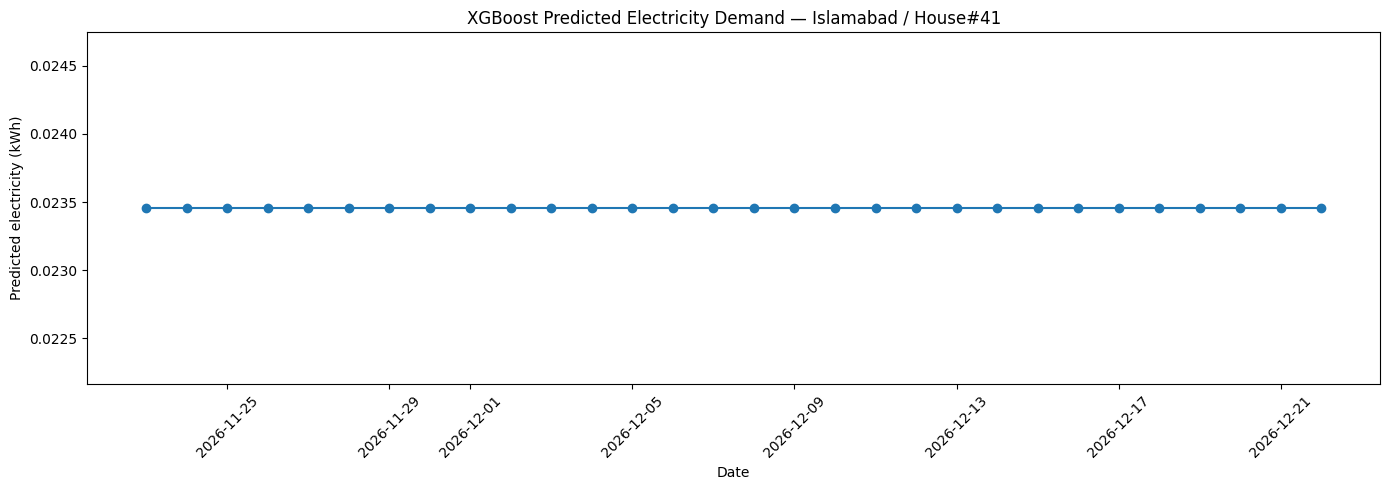

In [14]:
# 14. FINAL USER INPUT PREDICTION OUTPUT

print("\n" + "=" * 80)
print("POWERPLUS — XGBOOST USER INPUT PREDICTION OUTPUT")
print("=" * 80)
print(f"City              : {USER_CITY}")
print(f"House             : {USER_HOUSE}")
print(f"Forecast start    : {START_DATE.date()}")
print(f"Horizon requested : {HORIZON_DAYS} day(s)")
print("-" * 80)

print(f"1-Day predicted household demand  : {forecast_1['predicted_electricity_kwh'].sum():.4f} kWh")
print(f"7-Day predicted household demand  : {forecast_7['predicted_electricity_kwh'].sum():.4f} kWh")
print(f"30-Day predicted household demand : {forecast_30['predicted_electricity_kwh'].sum():.4f} kWh")

print("\nSELECTED USER INPUTS")
display(
    user_input_df[
        ["label", "model_type", "pandas_dtype",
         "python_input_type", "user_value"]
    ]
)

print("\nPREDICTION OUTPUT")
if HORIZON_DAYS == 1:
    display(forecast_1)
elif HORIZON_DAYS == 7:
    display(forecast_7)
else:
    display(forecast_30)

plt.figure(figsize=(14, 5))
plt.plot(
    forecast_30["date"],
    forecast_30["predicted_electricity_kwh"],
    marker="o"
)
plt.title(
    f"XGBoost Predicted Electricity Demand — "
    f"{USER_CITY} / {USER_HOUSE}"
)
plt.xlabel("Date")
plt.ylabel("Predicted electricity (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## How to use

1. Run the cells from top to bottom.
2. Select **City** and **House** using the numbered options.
3. For every categorical field, either enter its number or type the value. **Letter case does not matter**.
   - Example: training value `Owner` accepts `Owner`, `owner`, or `OWNER`.
   - Example: training value `Concrete` accepts `Concrete`, `concrete`, or `CONCRETE`.
4. For numeric fields, enter a number or press Enter to use the shown default.
5. The notebook saves the exact feature labels, datatypes, allowed values and user answers.
6. The final section gives the XGBoost prediction output and appliance sensitivity analysis.

**Note:** The current target is total household `electricity_kwh`. Appliance sensitivity shows the model's change in total household prediction when an appliance count changes; it is not a direct appliance-level energy meter.